# Tutorial on inference with SPEXAI

This tutorial explains how you can use SPEXAI to fit observered spectra from a FITS file.

In [1]:
%load_ext autoreload
%autoreload 2 
%aimport spexai.inference

%matplotlib notebook
import matplotlib.pyplot as plt

import numpy as np
import pickle
import torch
import scipy.constants as constants
#from spexai.inference import SingleTemp, TwoTemp, TempDist
#from spexai.inference import CombinedModel

In [2]:
#intial guess and prior for fit
prior = {
        'temp': {'mu': 5,    'sigma': 2},
        'met' : {'mu': 1,    'sigma': .3},
        'vel' : {'mu': 100,  'sigma': 50},
        'logz': {'mu': -5,   'sigma': 2},
        'norm': {'mu': 1e10, 'sigma': 1e9}
        }

datadir = "/Users/daniela/work/data/xrism/"
nn_dir = "/Users/daniela/work/repositories/spexai/neuralnetworks/"

combined_model = spexai.inference.model.CombinedModel(lumdist=1e25, 
                                                      fdir_nn=nn_dir)

combined_model.load_matrices(datadir)

#reading in the effective area
combined_model.load_arf(datadir+'/resolve_pnt_spec_noGV_20190611.arf')

params = {'temp':5,'logz':-2, 'vel':100, 'met':1.2, 'norm':1e10, 'Z8':1.2, 'Z14':0.9}

#intialize list of abunadace
dict_abund = {}
for i in torch.arange(6,31):
    dict_abund[f'Z{i}'] = params['met']
    for key in params.keys():
        if key == f'Z{i}':
            dict_abund[f'Z{i}'] = params['met']*params[f'Z{i}']

temp = torch.tensor([params['temp']], dtype=torch.float32)

ymodel = combined_model.emulator_model(temp, dict_abund, params["norm"])

### Diagnosing the Broadening Function

Let's see if we can make this faster:

In [3]:
def broadening(spectra, velocity, model):
    '''
    This function applies the velocity broadening on the spectra with a 
    convolution with a gaussion
    
    Parameters
    ----------
    spectra: tensor
        spectra before velocity broadening
    velocity: float
       velocity broading of turbulance [km/sec]
    '''
    if velocity < 1e-30:
        return spectra
#        velocity = 1e-30

    shape = (len(model.e_cent), len(model.e_cent))
    #tensor function to calculate pdf-value of the normal distribution
    normal = lambda x, stdev : torch.exp(torch.tensor(-0.5, dtype=torch.float32, device=x.device)*torch.pow(torch.div(x,stdev.to(x.device)), torch.tensor(2, dtype=torch.float32, device=x.device)))

    #use x_values to construct sparse matrix of normaldistributions 
    prev_values = model.sm_x._values().type(torch.float32)
    values = normal(prev_values.to(spectra.device), torch.tensor(velocity*1e3/constants.c, dtype=torch.float32)).cpu()

    normal_matrix = torch.sparse_coo_tensor(model.sm_x._indices(), values,  shape)

    #normalise the normal distribution
    values = (torch.tensor(1, dtype=torch.float32, device=spectra.device)/torch.sparse.mm(normal_matrix.to(spectra.device), model.e_diff.view(-1,1).to(spectra.device)).flatten()).cpu()
    normilisation = torch.sparse_coo_tensor(model.diag_index, values, shape)
    normal_matrix = torch.sparse.mm(normilisation.to(spectra.device), normal_matrix.to(spectra.device)).cpu()

    #convolve the normaldistributions with the spectrum
    spectra_dx = spectra.view(-1,1)*model.e_diff.view(-1,1).to(spectra.device)
    return torch.sparse.mm(normal_matrix.to(spectra.device), spectra_dx).flatten()



In [4]:
%timeit broadening(ymodel, 100, combined_model)

/var/folders/cm/2d1tk8fs125435tgbw22nb0h0000gp/T/ipykernel_99631/3375493907.py:30: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1682343679700/work/aten/src/ATen/SparseCsrTensorImpl.cpp:56.)
  normal_matrix = torch.sparse.mm(normilisation.to(spectra.device), normal_matrix.to(spectra.device)).cpu()


811 ms ± 52.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [5]:
%load_ext line_profiler

In [7]:
%lprun -f broadening broadening(ymodel, 100, combined_model)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


### CSR Line Broadening Function


In [18]:
def broadening_csr(spectrum, velocity, model):
    '''
    This function applies the velocity broadening on the spectra with a 
    convolution with a gaussion
    
    Parameters
    ----------
    spectra: tensor
        spectra before velocity broadening
    velocity: float
       velocity broading of turbulance [km/sec]
    '''
    if velocity < 1e-30:
        return spectrum
#        velocity = 1e-30

    shape = (len(model.e_cent), len(model.e_cent))
    #tensor function to calculate pdf-value of the normal distribution
    normal = lambda x, stdev : torch.exp(torch.tensor(-0.5, dtype=torch.float32, device=x.device)*torch.pow(torch.div(x,stdev.to(x.device)), torch.tensor(2, dtype=torch.float32, device=x.device)))

    prev_values = model.sm_x_csr.values().type(torch.float32)
    stdev = torch.tensor(velocity*1e3/constants.c, dtype=torch.float32)
    
    gaussian_values = normal(prev_values.to(spectrum.device), stdev).cpu()
    
    normal_matrix = torch.sparse_csr_tensor(model.sm_x_csr.crow_indices(), model.sm_x_csr.col_indices(), gaussian_values, shape, dtype=torch.float32)
    normalisation_values = (torch.tensor(1, dtype=torch.float32, device=spectrum.device)/torch.mv(normal_matrix.to(spectrum.device), combined_model.e_diff.to(spectrum.device)).flatten()).cpu()
    normal_matrix_new = normal_matrix.to_sparse_coo() * normalisation_values[:,None]
    normal_matrix_new = normal_matrix_new.to_sparse_csr()
    
    #convolve the normal distributions with the spectrum
    spectrum_dx = spectrum.view(-1,1)*combined_model.e_diff.view(-1,1).to(spectrum.device)
    spectrum_broad = torch.sparse.mm(normal_matrix_new.to(spectrum.device), spectrum_dx).flatten()
    
    return spectrum_broad

We need the original matrix in compressed sparse row format. The conversion is slow but only needs to be done once (and if we can figure out the indices, we can just construct it from the start in the relevant function in `write_tensors`:

In [10]:
combined_model.sm_x_csr = combined_model.sm_x.to_sparse_csr()

In [14]:
spec_b_old = broadening(ymodel, 100, combined_model)
spec_b_new = broadening_csr(ymodel, 100, combined_model)

In [15]:
%timeit spec_b_old = broadening(ymodel, 100, combined_model)

827 ms ± 32.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [16]:
%timeit spec_b_new = broadening_csr(ymodel, 100, combined_model)

165 ms ± 9.56 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [149]:
%lprun -f broadening_csr broadening_csr(ymodel, 100, combined_model)

### Can we make this faster with Cumulative Distributions?

Let's look at the relevant code:

In [93]:
combined_model.e

AttributeError: 'CombinedModel' object has no attribute 'e_low'

In [94]:
def make_sparsex_cdf(x, n=300):
    ''' '
    Will fill a sparse matrix with energies around a central energy and will 
    transform the energies with a factor of itself
    Parameters
    ----------
    x: tensor
        energy grid spectra
    n: int, default:300
        kernel size of the convolution
    '''
    column_index = torch.tensor([])
    row_index = torch.tensor([])
    x_values = torch.tensor([])

    for i, x_i in enumerate(x):
        full_col = torch.arange(-int((n/25)*x_i), int((n/25)*x_i), dtype=torch.long)+i
        full_col = full_col[full_col >= 0]
        col = full_col[full_col <= len(x)-1]
        row = torch.ones_like(col)*i
        x_row = (x[col]-x_i)/x_i

        column_index = torch.cat((column_index, col)).type(torch.long)
        row_index = torch.cat((row_index, row))
        x_low = torch.cat((x_values, x_row))

    index = torch.cat((row_index.view(1,-1), column_index.view(1,-1)))
    sparse_x = torch.sparse_coo_tensor(index, x_values, (len(x), len(x))).type(torch.float32)
    return sparse_x

Let's make an example array so I can play around with this more easily:

In [32]:
ndim = 500
x = torch.linspace(1, 500, ndim)

In [25]:
sparse_x = make_sparsex(x, n=100)

In [31]:
test_idx = 400
sparse_x._values()[sparse_x._indices()[0] == test_idx]

tensor([-0.9975, -0.9950, -0.9925, -0.9900, -0.9875, -0.9850, -0.9825, -0.9800,
        -0.9776, -0.9751, -0.9726, -0.9701, -0.9676, -0.9651, -0.9626, -0.9601,
        -0.9576, -0.9551, -0.9526, -0.9501, -0.9476, -0.9451, -0.9426, -0.9401,
        -0.9377, -0.9352, -0.9327, -0.9302, -0.9277, -0.9252, -0.9227, -0.9202,
        -0.9177, -0.9152, -0.9127, -0.9102, -0.9077, -0.9052, -0.9027, -0.9002,
        -0.8978, -0.8953, -0.8928, -0.8903, -0.8878, -0.8853, -0.8828, -0.8803,
        -0.8778, -0.8753, -0.8728, -0.8703, -0.8678, -0.8653, -0.8628, -0.8603,
        -0.8579, -0.8554, -0.8529, -0.8504, -0.8479, -0.8454, -0.8429, -0.8404,
        -0.8379, -0.8354, -0.8329, -0.8304, -0.8279, -0.8254, -0.8229, -0.8204,
        -0.8180, -0.8155, -0.8130, -0.8105, -0.8080, -0.8055, -0.8030, -0.8005,
        -0.7980, -0.7955, -0.7930, -0.7905, -0.7880, -0.7855, -0.7830, -0.7805,
        -0.7781, -0.7756, -0.7731, -0.7706, -0.7681, -0.7656, -0.7631, -0.7606,
        -0.7581, -0.7556, -0.7531, -0.75

In [33]:
sparse_x_csr = sparse_x.to_sparse_csr()

In [69]:
velocity = 100000.0
shape = (ndim, ndim)
#tensor function to calculate pdf-value of the normal distribution
normal = lambda x, stdev : torch.exp(torch.tensor(-0.5, dtype=torch.float32, device=x.device)*torch.pow(torch.div(x,stdev.to(x.device)), torch.tensor(2, dtype=torch.float32, device=x.device)))

prev_values = sparse_x_csr.values().type(torch.float32)
stdev = torch.tensor(velocity*1e3/constants.c, dtype=torch.float32)

gaussian_values = normal(prev_values, stdev).cpu()

normal_matrix = torch.sparse_csr_tensor(sparse_x_csr.crow_indices(), sparse_x_csr.col_indices(), gaussian_values, shape, dtype=torch.float32)


In [70]:
normal_matrix_coo = normal_matrix.to_sparse_coo()

In [71]:
len(sparse_x._indices()[0] == test_idx)

225150

In [72]:
test_idx = 10

In [73]:
sparse_x._indices()[1][sparse_x._indices()[0] == test_idx]

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53])

<IPython.core.display.Javascript object>


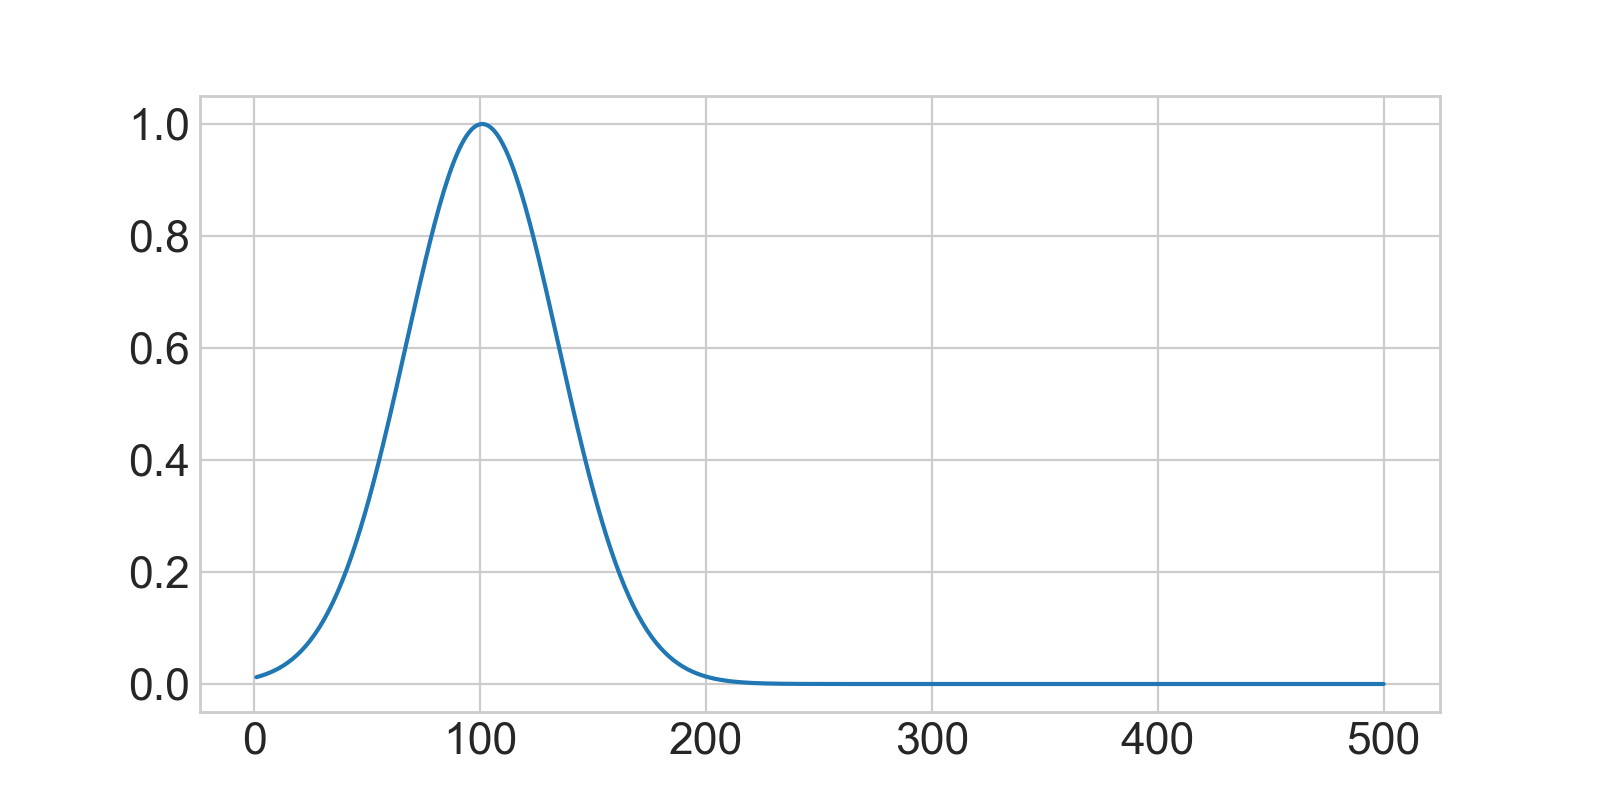

In [143]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))

test_idx = 100
xtest = x[sparse_x._indices()[1][sparse_x._indices()[0] == test_idx]]
mtest = normal_matrix_coo._values()[sparse_x._indices()[0] == test_idx]

plt.plot(xtest, mtest)

### What if I do this, but with the CDF?

In [ ]:
    ''' '
    Will fill a sparse matrix with energies around a central energy and will transform the energies with a factor of itself
    Parameters
    ----------
    x: tensor
        energy grid spectra
    n: int, default:300
        kernel size of the convolution
    '''
    collumn_index = torch.tensor([])
    row_index = torch.tensor([])
    x_values = torch.tensor([])

    for i, x_i in enumerate(x):
        full_col = torch.arange(-int((n/25)*x_i), int((n/25)*x_i), dtype=torch.long)+i
        full_col = full_col[full_col >= 0]
        col = full_col[full_col <= len(x)-1]
        row = torch.ones_like(col)*i
        x_row = (x[col]-x_i)/x_i

        collumn_index = torch.cat((collumn_index, col)).type(torch.long)
        row_index = torch.cat((row_index, row))
        x_values = torch.cat((x_values, x_row))

    index = torch.cat((row_index.view(1,-1), collumn_index.view(1,-1)))
    sparse_x = torch.sparse_coo_tensor(index, x_values, (len(x), len(x))).type(torch.float32)
    return sparse_x


In [106]:
def make_sparsex_cdf(x, x_diff, n=300):
    ''' '
    Will fill a sparse matrix with energies around a central energy and will 
    transform the energies with a factor of itself
    Parameters
    ----------
    x: tensor
        energy grid spectra
    n: int, default:300
        kernel size of the convolution
    '''
    column_index = torch.tensor([])
    row_index = torch.tensor([])
    x_vals_low = torch.tensor([])
    x_vals_high = torch.tensor([])

    x_low = x - 0.5*x_diff
    x_high = x + 0.5*x_diff

    for i, x_i in enumerate(x):
        full_col = torch.arange(-int((n/25)*x_i), int((n/25)*x_i), dtype=torch.long)+i
        full_col = full_col[full_col >= 0]
        col = full_col[full_col <= len(x)-1]
        row = torch.ones_like(col)*i
        x_row_low = (x_low[col]-x_i)/x_i
        x_row_high = (x_high[col]-x_i)/x_i

        column_index = torch.cat((column_index, col)).type(torch.long)
        row_index = torch.cat((row_index, row))
        x_vals_low = torch.cat((x_vals_low, x_row_low))
        x_vals_high = torch.cat((x_vals_high, x_row_high))


    index = torch.cat((row_index.view(1,-1), column_index.view(1,-1)))
    sparse_x_low = torch.sparse_coo_tensor(index, x_vals_low, (len(x), len(x))).type(torch.float32)
    sparse_x_high = torch.sparse_coo_tensor(index, x_vals_high, (len(x), len(x))).type(torch.float32)
    return sparse_x_low, sparse_x_high

In [79]:
def normal_cdf(x_low, x_high, stdev):
    m = torch.distributions.Normal(0, torch.tensor(velocity*1e3/constants.c, dtype=torch.float32))
    n_high = m.cdf(x_high)
    n_low = m.cdf(x_low)
    
    return n_high-n_low

In [103]:
dx = x[1] - x[0]
x_low = x - 0.5*dx
x_high = x + 0.5*dx

In [104]:
x_diff = x_high - x_low

In [130]:
sparse_x_low, sparse_x_high = make_sparsex_cdf(x_low, x_high, n=100)
sparse_x_low_csr = sparse_x_low.to_sparse_csr()
sparse_x_high_csr = sparse_x_high.to_sparse_csr()

In [131]:
sparse_x = make_sparsex(x, n=100)

In [132]:
sparse_x_low

tensor(indices=tensor([[  0,   0,   1,  ..., 499, 499, 499],
                       [  0,   1,   0,  ..., 497, 498, 499]]),
       values=tensor([-1.5000, -0.5000, -1.1667,  ..., -0.5030, -0.5020,
                      -0.5010]),
       size=(500, 500), nnz=224950, layout=torch.sparse_coo)

In [133]:
sparse_x_high

tensor(indices=tensor([[  0,   0,   1,  ..., 499, 499, 499],
                       [  0,   1,   0,  ..., 497, 498, 499]]),
       values=tensor([ 1.5000,  4.5000, -0.1667,  ...,  0.4950,  0.4980,
                       0.5010]),
       size=(500, 500), nnz=224950, layout=torch.sparse_coo)

In [134]:
sparse_x

tensor(indices=tensor([[  0,   0,   0,  ..., 499, 499, 499],
                       [  0,   1,   2,  ..., 497, 498, 499]]),
       values=tensor([ 0.0000,  1.0000,  2.0000,  ..., -0.0040, -0.0020,
                       0.0000]),
       size=(500, 500), nnz=225150, layout=torch.sparse_coo)

In [135]:
prev_values_low = sparse_x_low._values()
prev_values_high = sparse_x_high._values()

In [136]:
m = torch.distributions.Normal(0, torch.tensor(velocity*1e3/constants.c, dtype=torch.float32))
ncdf = m.cdf(prev_values_high) - m.cdf(prev_values_low)


In [137]:
normal_matrix_cdf = torch.sparse_csr_tensor(sparse_x_low_csr.crow_indices(), sparse_x_low_csr.col_indices(), ncdf, shape, dtype=torch.float32)

normal_matrix_coo_cdf = normal_matrix_cdf.to_sparse_coo()

In [142]:
sparse_x._values()[sparse_x._indices()[0] == test_idx]

tensor([-0.9524, -0.9048, -0.8571, -0.8095, -0.7619, -0.7143, -0.6667, -0.6190,
        -0.5714, -0.5238, -0.4762, -0.4286, -0.3810, -0.3333, -0.2857, -0.2381,
        -0.1905, -0.1429, -0.0952, -0.0476,  0.0000,  0.0476,  0.0952,  0.1429,
         0.1905,  0.2381,  0.2857,  0.3333,  0.3810,  0.4286,  0.4762,  0.5238,
         0.5714,  0.6190,  0.6667,  0.7143,  0.7619,  0.8095,  0.8571,  0.9048,
         0.9524,  1.0000,  1.0476,  1.0952,  1.1429,  1.1905,  1.2381,  1.2857,
         1.3333,  1.3810,  1.4286,  1.4762,  1.5238,  1.5714,  1.6190,  1.6667,
         1.7143,  1.7619,  1.8095,  1.8571,  1.9048,  1.9524,  2.0000,  2.0476,
         2.0952,  2.1429,  2.1905,  2.2381,  2.2857,  2.3333,  2.3810,  2.4286,
         2.4762,  2.5238,  2.5714,  2.6190,  2.6667,  2.7143,  2.7619,  2.8095,
         2.8571,  2.9048,  2.9524,  3.0000,  3.0476,  3.0952,  3.1429,  3.1905,
         3.2381,  3.2857,  3.3333,  3.3810,  3.4286,  3.4762,  3.5238,  3.5714,
         3.6190,  3.6667,  3.7143,  3.76

<IPython.core.display.Javascript object>


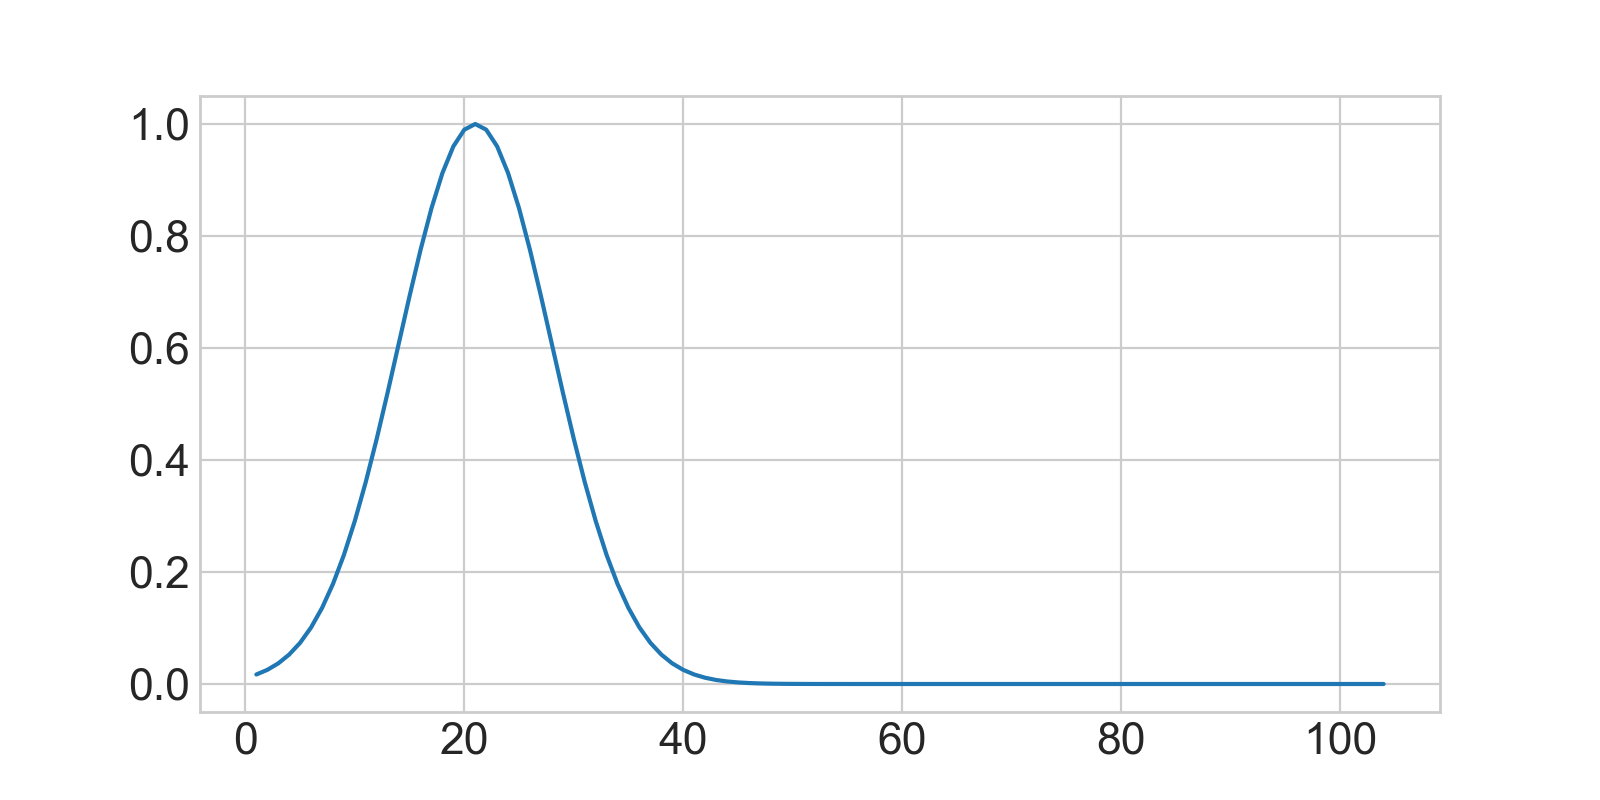

In [145]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))

test_idx = 20
xtest = x[sparse_x._indices()[1][sparse_x._indices()[0] == test_idx]]
mtest = normal_matrix_coo._values()[sparse_x._indices()[0] == test_idx]

plt.plot(xtest, mtest)

<IPython.core.display.Javascript object>


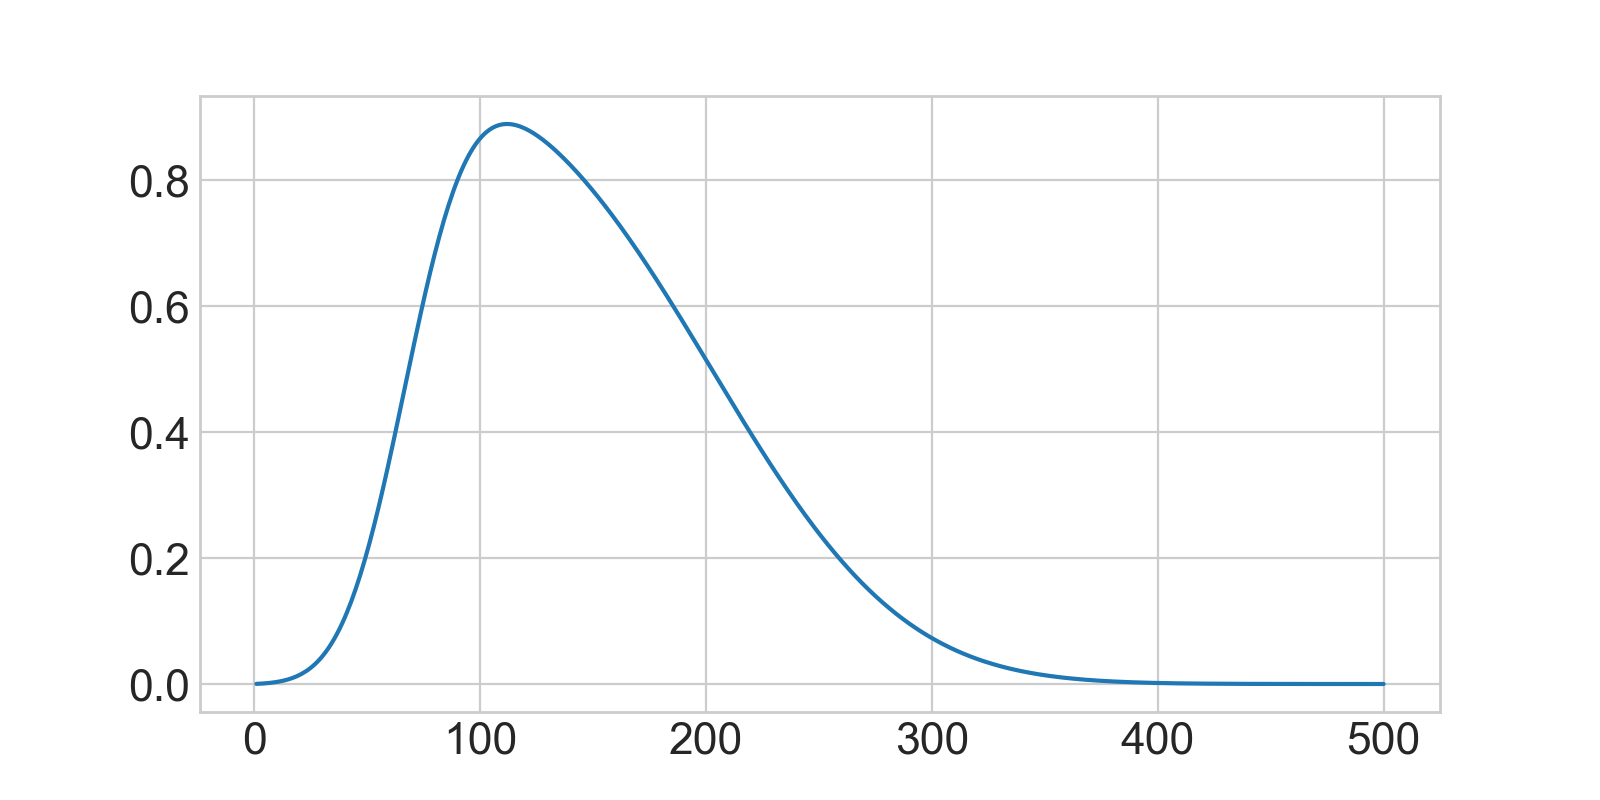

In [150]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))

test_idx = 100
xtest = x[sparse_x_low._indices()[1][sparse_x_low._indices()[0] == test_idx]]
mtest = normal_matrix_coo_cdf._values()[sparse_x_low._indices()[0] == test_idx]

plt.plot(xtest, mtest)

In [87]:
u = torch.linspace(-10, 10, 1000)
u_low = u - 0.5*(u[1]-u[0])
u_high = u + 0.5*(u[1]-u[0])

In [88]:
ntest = normal_cdf(u_low, u_high, stdev)

In [92]:
torch.sum(ntest)

tensor(1.0000)

<IPython.core.display.Javascript object>


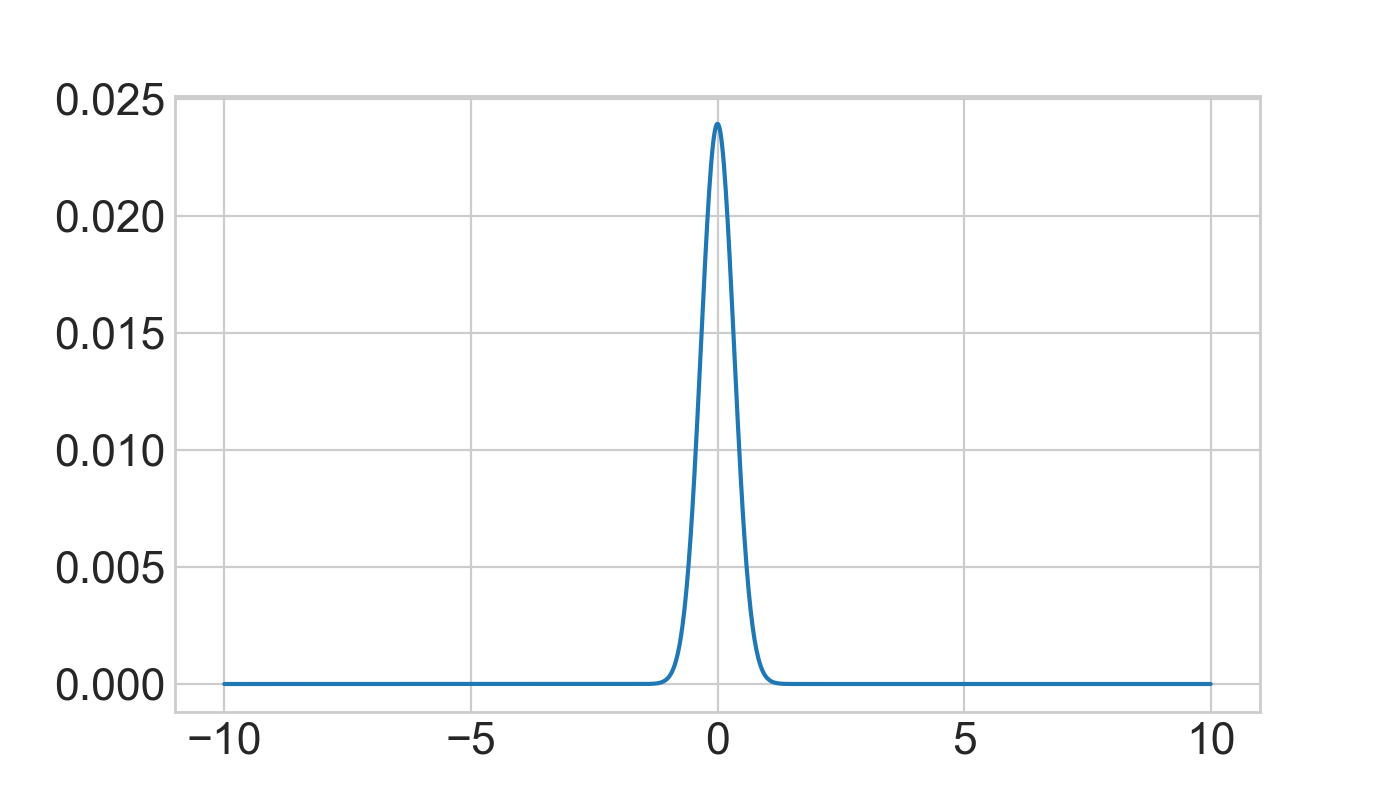

In [91]:
fig, ax = plt.subplots(1, 1, figsize=(7,4))

ax.plot(u, ntest)

In [ ]:
gaussian_values_cdf = normal_cdf(prev_values, stdev).cpu()

normal_matrix = torch.sparse_csr_tensor(sparse_x_csr.crow_indices(), sparse_x_csr.col_indices(), gaussian_values, shape, dtype=torch.float32)


In [ ]:
normal = lambda x, stdev : torch.exp(torch.tensor(-0.5, dtype=torch.float32, device=x.device)*torch.pow(torch.div(x,stdev.to(x.device)), torch.tensor(2, dtype=torch.float32, device=x.device)))


### Looking at the function line by line

Let's look at the function line by line:

In [4]:
shape = (len(combined_model.e_cent), len(combined_model.e_cent))


In [5]:
normal = lambda x, stdev : torch.exp(torch.tensor(-0.5, dtype=torch.float32, device=x.device)*torch.pow(torch.div(x,stdev.to(x.device)), torch.tensor(2, dtype=torch.float32, device=x.device)))


In [6]:
sm_x_csr = combined_model.sm_x.to_sparse_csr()

/var/folders/cm/2d1tk8fs125435tgbw22nb0h0000gp/T/ipykernel_81533/2993369288.py:1: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1682343679700/work/aten/src/ATen/SparseCsrTensorImpl.cpp:56.)
  sm_x_csr = combined_model.sm_x.to_sparse_csr()


In [7]:
#import pickle
#with open(datadir+"sm_x_csr.pkl", "wb") as file:
#    pickle.dump(sm_x_csr, file)

In [57]:
prev_values = combined_model.sm_x._values().type(torch.float32)

In [9]:
#%timeit prev_values = combined_model.sm_x._values().type(torch.float32)

In [58]:
prev_values_csr = sm_x_csr.values().type(torch.float32)

In [11]:
#%timeit prev_values_csr = sm_x_csr.values().type(torch.float32)

### Comparing Jip's function to torch.distributions

In [145]:
def normal(x, stdev):
    prefac = 1.0
    #prefac = torch.div(1, torch.sqrt(2*torch.pi*torch.pow(stdev, torch.tensor(2, dtype=torch.float32, device=x.device))))
    norm_fac = torch.pow(torch.div(x,stdev.to(x.device)), torch.tensor(2, dtype=torch.float32, device=x.device))
    return prefac*torch.exp(torch.tensor(-0.5, dtype=torch.float32, device=x.device)*norm_fac)

In [160]:
velocity = 100.0
m = torch.distributions.Normal(0, torch.tensor(velocity*1e3/constants.c, dtype=torch.float32))

In [257]:
x = torch.linspace(-0.01, 0.01, 10000)
njip = normal(x,  torch.tensor(velocity*1e3/constants.c, dtype=torch.float32))


In [267]:
dx = x[1] - x[0]
x_diff = torch.ones_like(x)*dx
ntorch = m.cdf(x[1:])- m.cdf(x[:-1])

In [268]:
ntorch

tensor([0., 0., 0.,  ..., 0., 0., 0.])

<IPython.core.display.Javascript object>


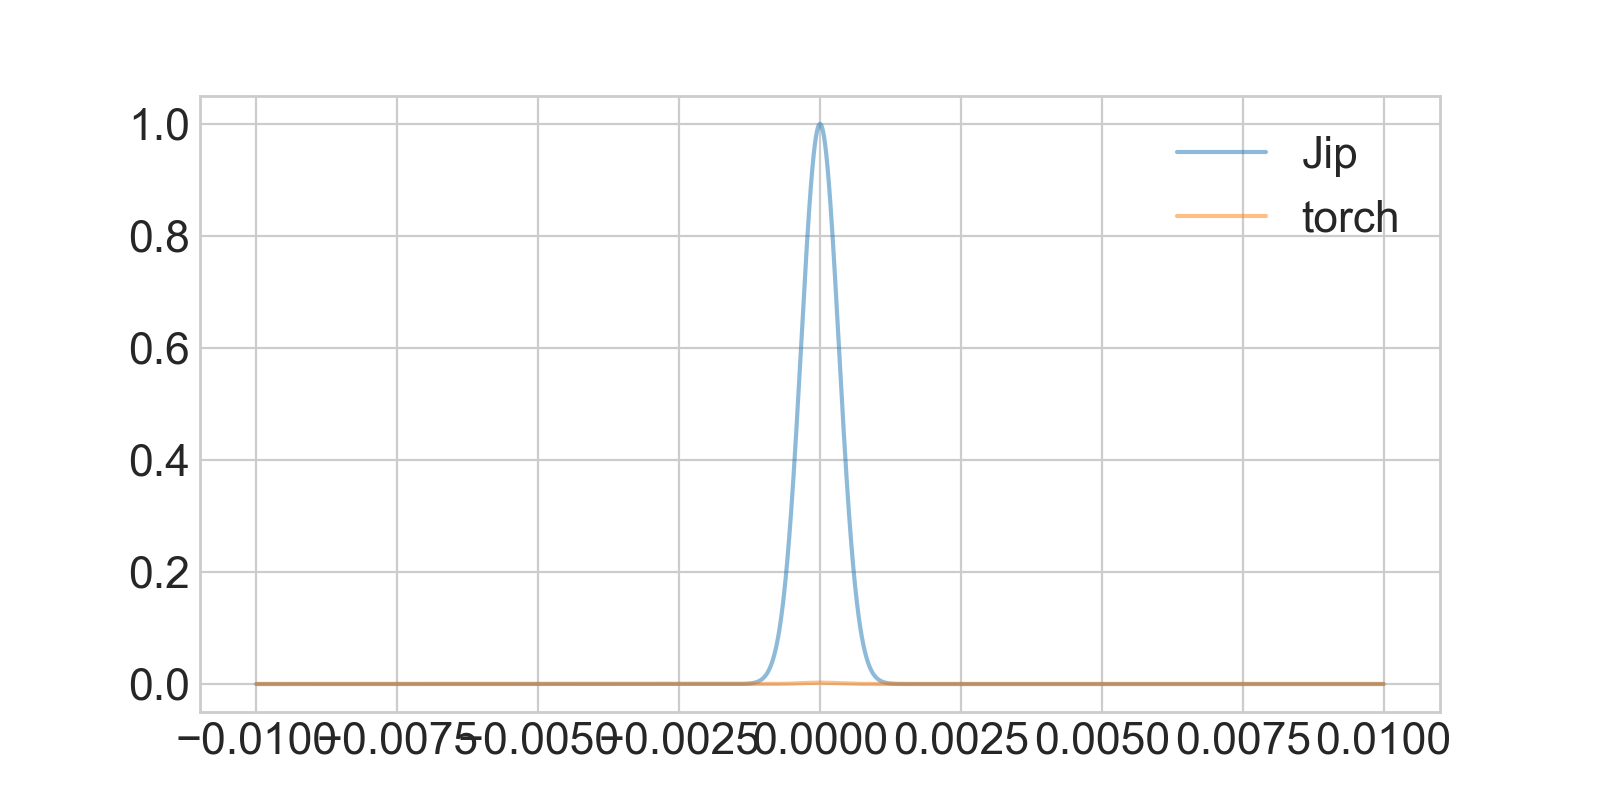

In [269]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))
ax.plot(x, njip.detach().numpy(), alpha=0.5, label="Jip")
ax.plot(x[:-1], ntorch.detach().numpy(), alpha=0.5, label="torch")

ax.legend()

In [219]:
torch.max(njip - ntorch)

tensor(0.)

Normalizing the normal distribution:

In [220]:
dx = x[1] - x[0]
x_diff = torch.ones_like(x)*dx

In [221]:
torch.sum(ntorch * x_diff)

tensor(0.7252)

In [222]:
torch.sum(njip * x_diff)

tensor(0.0006)

tensor([ 0.1002,  0.1007,  0.1011,  ..., 24.9233, 24.9237, 25.0214])

### Continuing with the Code

In [13]:
#%timeit torch.exp(m.log_prob(prev_values))

In [60]:
#%timeit normal(prev_values, torch.Tensor([100]))

In [74]:
velocity = 100.0
stdev = torch.tensor(velocity*1e3/constants.c, dtype=torch.float32)
gaussian_values = normal(prev_values.to(ymodel.device), stdev).cpu()

In [161]:
prefac = torch.div(1, torch.sqrt(2*torch.pi*torch.pow(stdev, torch.tensor(2, dtype=torch.float32, device=x.device))))
gauss_val_torch = torch.exp(m.log_prob(prev_values)) #/ prefac

In [162]:
gauss_val_torch

tensor([9.4865e-29, 1.1960e+03, 2.9736e-22,  ..., 1.0722e-27, 2.1647e-27,
        1.1960e+03])

In [163]:
gaussian_values

tensor([7.9318e-32, 1.0000e+00, 2.4863e-25,  ..., 8.9652e-31, 1.8099e-30,
        1.0000e+00])

In [164]:
#%timeit gauss_val_torch = torch.exp(m.log_prob(prev_values)) / prefac

65 ms ± 3.64 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [165]:
#%timeit gaussian_values = normal(prev_values.to(ymodel.device), torch.tensor(velocity*1e3/constants.c, dtype=torch.float32)).cpu()


In [166]:
normal_matrix = torch.sparse_coo_tensor(combined_model.sm_x._indices(), gaussian_values,  shape)

In [167]:
len(gauss_val_torch)

9904131

In [83]:
len(gaussian_values)

9904131

In [168]:
normal_matrix_torch = torch.sparse_coo_tensor(combined_model.sm_x._indices(), gauss_val_torch,  shape)

In [169]:
normal_matrix_csr = torch.sparse_csr_tensor(sm_x_csr.crow_indices(), sm_x_csr.col_indices(), gaussian_values, shape, dtype=torch.float32)

In [170]:
torch.sum((normal_matrix._indices()[0] == 20000))

tensor(158)

In [171]:
len(normal_matrix._indices()[0])

9904131

<IPython.core.display.Javascript object>


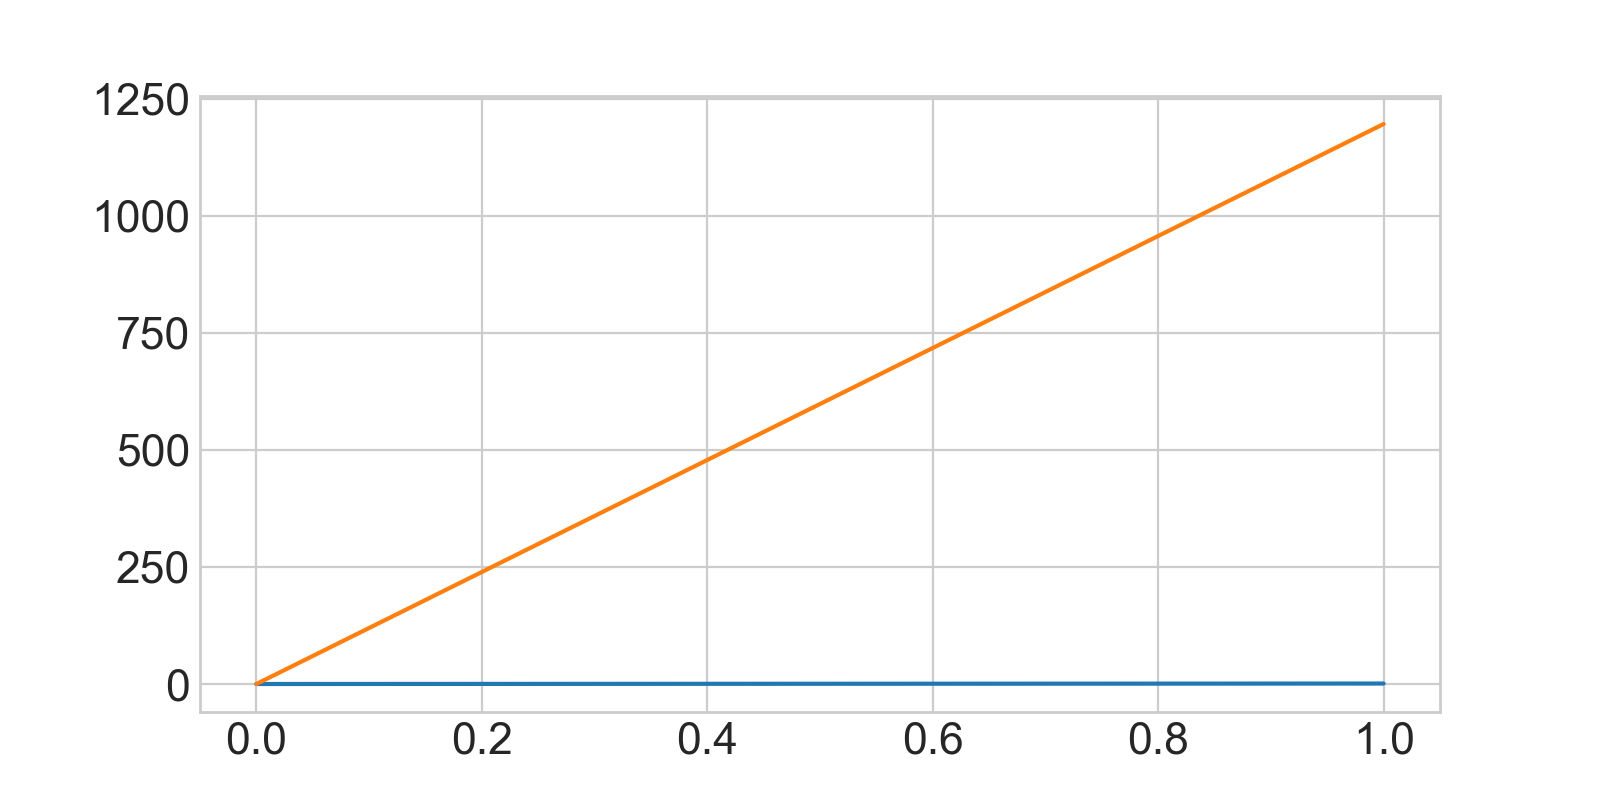

In [225]:
test_idx = 100
fig, ax = plt.subplots(1, 1, figsize=(8,4))

ax.plot(normal_matrix._values()[(normal_matrix._indices()[0] == test_idx)])
ax.plot(normal_matrix_torch._values()[(normal_matrix._indices()[0] == test_idx)])


In [28]:
#%timeit normalisation_values = (torch.tensor(1, dtype=torch.float32, device=ymodel.device)/torch.sparse.mm(normal_matrix.to(ymodel.device), combined_model.e_diff.view(-1,1).to(ymodel.device)).flatten()).cpu()


In [29]:
#%timeit normalisation_values_csr = (torch.tensor(1, dtype=torch.float32, device=ymodel.device)/torch.sparse.mm(normal_matrix_csr.to(ymodel.device), combined_model.e_diff.view(-1,1).to(ymodel.device)).flatten()).cpu()

In [173]:
normalisation_values = (torch.tensor(1, dtype=torch.float32, device=ymodel.device)/torch.sparse.mm(normal_matrix.to(ymodel.device), combined_model.e_diff.view(-1,1).to(ymodel.device)).flatten()).cpu()

In [174]:
normalisation_values_csr = (torch.tensor(1, dtype=torch.float32, device=ymodel.device)/torch.mm(normal_matrix_csr.to(ymodel.device), combined_model.e_diff.view(-1, 1).to(ymodel.device)).flatten()).cpu()

In [175]:
normalisation_values.shape

torch.Size([50125])

In [176]:
normalisation = torch.sparse_coo_tensor(combined_model.diag_index, normalisation_values_csr, shape)

In [177]:
normalisation_csr = torch.sparse_coo_tensor(combined_model.diag_index, normalisation_values_csr, shape).to_sparse_csr()

In [178]:
#%timeit normalisation = torch.sparse_coo_tensor(combined_model.diag_index, normalisation_values_csr, shape)

**TODO**: Fix the line below

In [293]:
%timeit normalisation_csr = torch.sparse_coo_tensor(combined_model.diag_index, normalisation_values_csr, shape).to_sparse_csr()

1.07 ms ± 201 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


#### Do I need matrix multiplication for the normalization factor?

In [312]:
%timeit normal_matrix * normalisation_values[:,None]

48.8 ms ± 1.77 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [304]:
torch.mv(normal_matrix_csr, normalisation_values)

tensor([   0.0000,    0.0000,    0.0000,  ..., 1471.2220, 1414.9296,
           5.1318])

tensor([[   0.0000],
        [   0.0000],
        [   0.0000],
        ...,
        [1471.2219],
        [1414.9297],
        [   5.1318]])

In [309]:
normal_matrix * normalisation_values[:,None]

tensor(indices=tensor([[   69,    69,    70,  ..., 50124, 50124, 50124],
                       [   68,    69,    69,  ..., 50122, 50123, 50124]]),
       values=tensor([1.5864e-28, 2.0000e+03, 6.3339e-22,  ...,
                      4.6008e-30, 9.2881e-30, 5.1318e+00]),
       size=(50125, 50125), nnz=9904131, layout=torch.sparse_coo)

In [308]:
torch.sparse.mm(normal_matrix_csr, normalisation_values[:, None])

tensor([[   0.0000],
        [   0.0000],
        [   0.0000],
        ...,
        [1471.2219],
        [1414.9297],
        [   5.1318]])

In [296]:
normal_matrix_new

tensor(indices=tensor([[   69,    69,    70,  ..., 50124, 50124, 50124],
                       [   68,    69,    69,  ..., 50122, 50123, 50124]]),
       values=tensor([1.5864e-28, 2.0000e+03, 6.3339e-22,  ...,
                      4.6008e-30, 9.2881e-30, 5.1318e+00]),
       size=(50125, 50125), nnz=9904131, layout=torch.sparse_coo)

Let's construct the new matrix:

In [298]:
%timeit normal_matrix_new = torch.sparse.mm(normalisation.to(ymodel.device), normal_matrix.to(ymodel.device)).cpu()


357 ms ± 19.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [179]:
normal_matrix_new = torch.sparse.mm(normalisation.to(ymodel.device), normal_matrix.to(ymodel.device)).cpu()

In [314]:
%timeit normal_matrix_new_csr = torch.sparse.mm(normalisation_csr.to(ymodel.device), normal_matrix_csr.to(ymodel.device)).cpu()

142 ms ± 24.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [180]:
normal_matrix_new_csr = torch.sparse.mm(normalisation_csr.to(ymodel.device), normal_matrix_csr.to(ymodel.device)).cpu()

In [231]:
test_idx = 40000
torch.sum(normal_matrix_torch._values()[(normal_matrix._indices()[0] == test_idx)]*combined_model.e_diff[normal_matrix_new._indices()[1][[(normal_matrix._indices()[0] == test_idx)]]])

tensor(19.8719)

In [232]:
torch.sum(normal_matrix_new._values()[(normal_matrix._indices()[0] == test_idx)]*combined_model.e_diff[normal_atrix_new._indices()[1][[(normal_matrix._indices()[0] == test_idx)]]])

tensor(1.0000)

In [132]:
normalisation_values = torch.tensor(1, dtype=torch.float32, device=ymodel.device)/torch.sparse.mm(normal_matrix_new.to(ymodel.device), combined_model.e_diff.view(-1,1).to(ymodel.device))

<IPython.core.display.Javascript object>


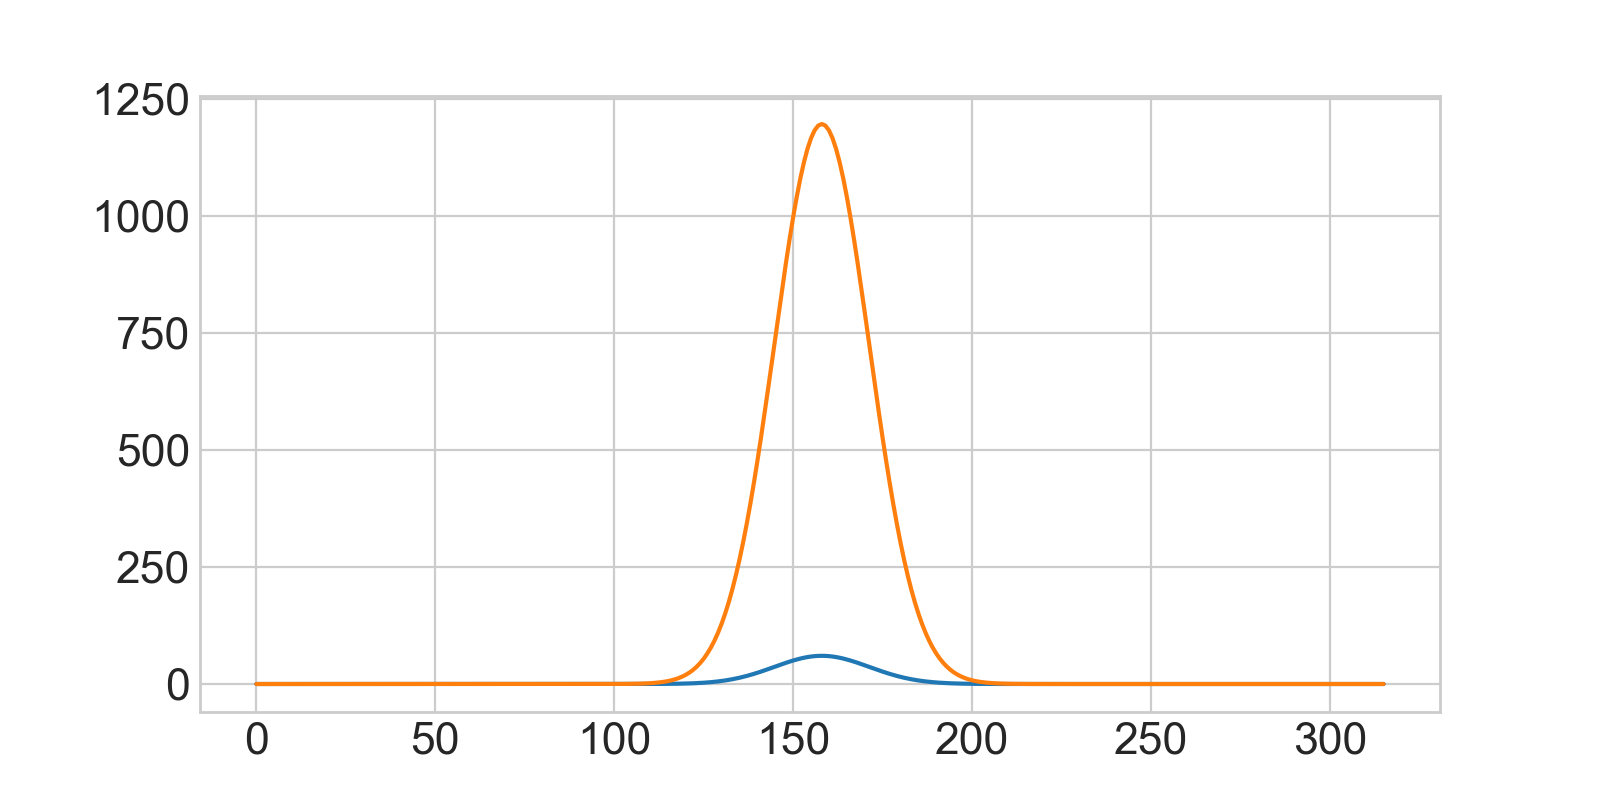

In [233]:
test_idx = 40000

fig, ax = plt.subplots(1, 1, figsize=(8,4))

ax.plot(normal_matrix_new._values()[(normal_matrix._indices()[0] == test_idx)])
ax.plot(normal_matrix_torch._values()[(normal_matrix._indices()[0] == test_idx)])


In [39]:
normal_matrix_new_csr

tensor(crow_indices=tensor([      0,       0,       0,  ..., 9903729,
                            9903930, 9904131]),
       col_indices=tensor([   68,    69,    69,  ..., 50122, 50123, 50124]),
       values=tensor([1.5864e-28, 2.0000e+03, 6.3339e-22,  ...,
                      4.6008e-30, 9.2881e-30, 5.1318e+00]),
       size=(50125, 50125), nnz=9904131, layout=torch.sparse_csr)

In [40]:
normal_matrix_torch

tensor(indices=tensor([[   69,    69,    70,  ..., 50124, 50124, 50124],
                       [   68,    69,    69,  ..., 50122, 50123, 50124]]),
       values=tensor([9.4865e-29, 1.1960e+03, 2.9736e-22,  ...,
                      1.0722e-27, 2.1647e-27, 1.1960e+03]),
       size=(50125, 50125), nnz=9904131, layout=torch.sparse_coo)

In [259]:
normal_matrix_new

tensor(indices=tensor([[   69,    69,    70,  ..., 50124, 50124, 50124],
                       [   68,    69,    69,  ..., 50122, 50123, 50124]]),
       values=tensor([1.5864e-28, 2.0000e+03, 6.3339e-22,  ...,
                      4.6008e-30, 9.2881e-30, 5.1318e+00]),
       size=(50125, 50125), nnz=9904131, layout=torch.sparse_coo)

In [41]:
#convolve the normaldistributions with the spectrum
ymodel_dx = ymodel.view(-1,1)*combined_model.e_diff.view(-1,1).to(ymodel.device)

In [265]:
%timeit ymodel_dx = ymodel.view(-1,1)*combined_model.e_diff.view(-1,1).to(ymodel.device)

18.2 µs ± 1.25 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [42]:
spectrum_broad = torch.sparse.mm(normal_matrix_new.to(ymodel.device), ymodel_dx).flatten()

In [273]:
%timeit spectrum_broad = torch.sparse.mm(normal_matrix_new.to(ymodel.device), ymodel_dx).flatten()

201 ms ± 36.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [43]:
spectrum_broad_csr = torch.sparse.mm(normal_matrix_new_csr.to(ymodel.device), ymodel_dx).flatten()

In [48]:
spectrum_broad_torch = torch.sparse.mm(normal_matrix_torch.to(ymodel.device), ymodel_dx).flatten()

In [49]:
spectrum_broad_torch

<IPython.core.display.Javascript object>


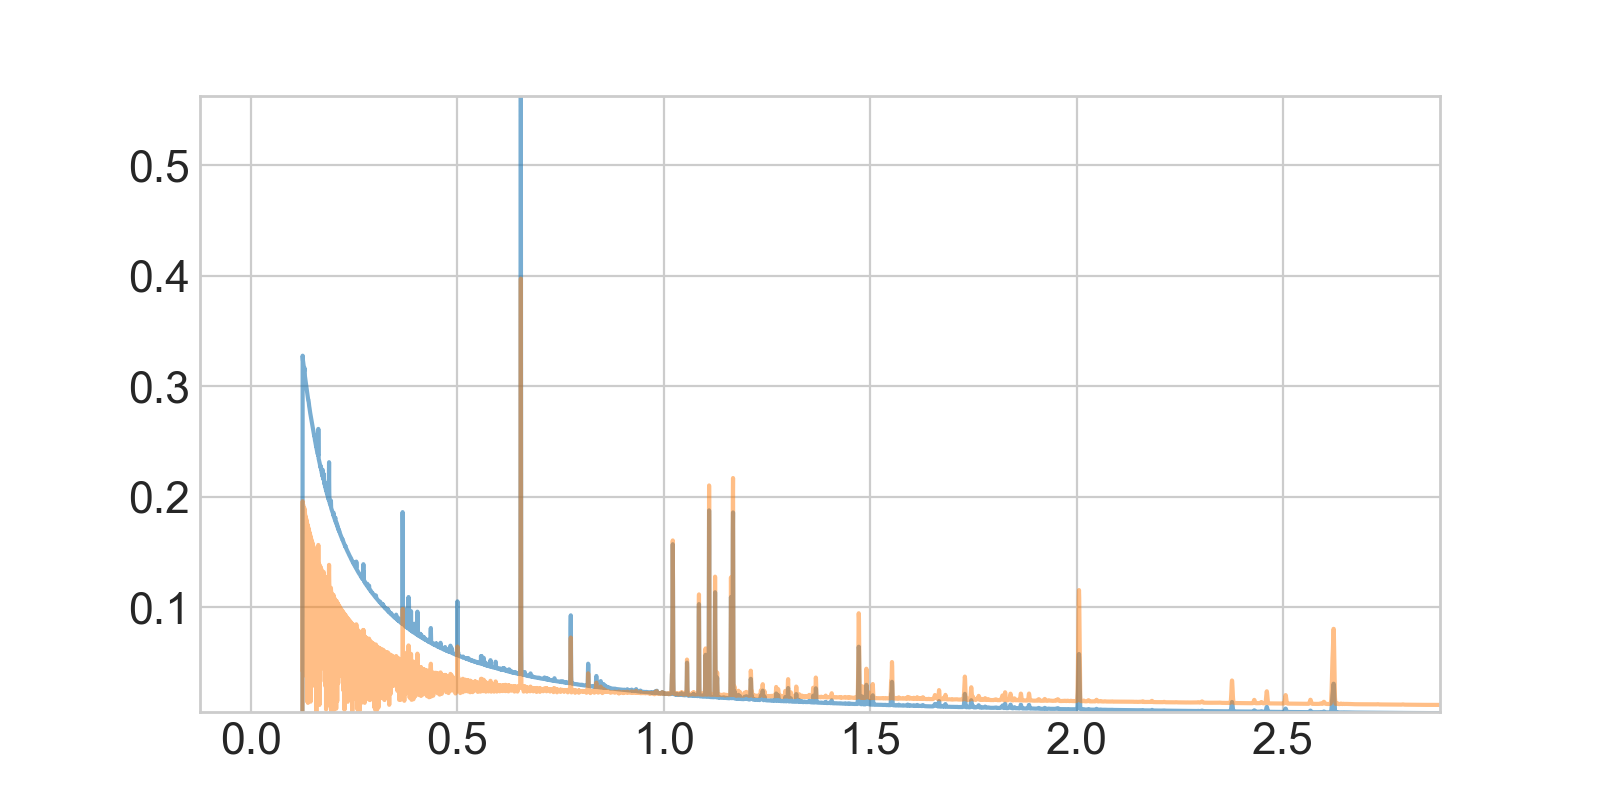

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))

ax.plot(combined_model.e_cent, spectrum_broad.detach().numpy(), alpha=0.6)
ax.plot(combined_model.e_cent, spectrum_broad_torch.detach().numpy(), alpha=0.5)

In [321]:
def broadening_csr(spectrum, velocity, model):
    '''
    This function applies the velocity broadening on the spectra with a 
    convolution with a gaussion
    
    Parameters
    ----------
    spectra: tensor
        spectra before velocity broadening
    velocity: float
       velocity broading of turbulance [km/sec]
    '''
    if velocity < 1e-30:
        return spectrum
#        velocity = 1e-30

    shape = (len(model.e_cent), len(model.e_cent))
    #tensor function to calculate pdf-value of the normal distribution
    normal = lambda x, stdev : torch.exp(torch.tensor(-0.5, dtype=torch.float32, device=x.device)*torch.pow(torch.div(x,stdev.to(x.device)), torch.tensor(2, dtype=torch.float32, device=x.device)))

    prev_values = model.sm_x_csr.values().type(torch.float32)
    stdev = torch.tensor(velocity*1e3/constants.c, dtype=torch.float32)
    
    gaussian_values = normal(prev_values.to(spectrum.device), stdev).cpu()
    
    normal_matrix = torch.sparse_csr_tensor(sm_x_csr.crow_indices(), sm_x_csr.col_indices(), gaussian_values, shape, dtype=torch.float32)
    normalisation_values = (torch.tensor(1, dtype=torch.float32, device=spectrum.device)/torch.mv(normal_matrix.to(spectrum.device), combined_model.e_diff.to(spectrum.device)).flatten()).cpu()
    #normalisation = torch.sparse_coo_tensor(combined_model.diag_index, normalisation_values_csr, shape).to_sparse_csr()
    #normal_matrix_new = torch.sparse.mm(normalisation.to(spectrum.device), normal_matrix.to(spectrum.device)).cpu()
    normal_matrix_new = normal_matrix.to_sparse_coo() * normalisation_values[:,None]
    normal_matrix_new = normal_matrix_new.to_sparse_csr()
    
    #convolve the normal distributions with the spectrum
    spectrum_dx = spectrum.view(-1,1)*combined_model.e_diff.view(-1,1).to(spectrum.device)
    spectrum_broad = torch.sparse.mm(normal_matrix_new.to(spectrum.device), spectrum_dx).flatten()
    
    return spectrum_broad

Let's compare:

In [288]:
combined_model.sm_x_csr = combined_model.sm_x.to_sparse_csr()

In [324]:
spec_b_old = broadening(ymodel, 100, combined_model)
spec_b_new = broadening_csr(ymodel, 100, combined_model)


In [317]:
spec_b_old

tensor([0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 3.0594e-06, 3.0593e-06,
        2.9801e-06], grad_fn=<ReshapeAliasBackward0>)

In [318]:
spec_b_new

tensor([0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 3.0594e-06, 3.0593e-06,
        2.9801e-06], grad_fn=<ReshapeAliasBackward0>)

In [278]:
torch.max(spec_b_new - spec_b_old)

tensor(5.9605e-08, grad_fn=<MaxBackward1>)

In [281]:
%timeit spec_b_old = broadening(ymodel, 100, combined_model)

815 ms ± 65.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [323]:
%timeit spec_b_new = broadening_csr(ymodel, 100, combined_model)

140 ms ± 4.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [322]:
lprun -f broadening_csr broadening_csr(ymodel, 100, combined_model)

<IPython.core.display.Javascript object>


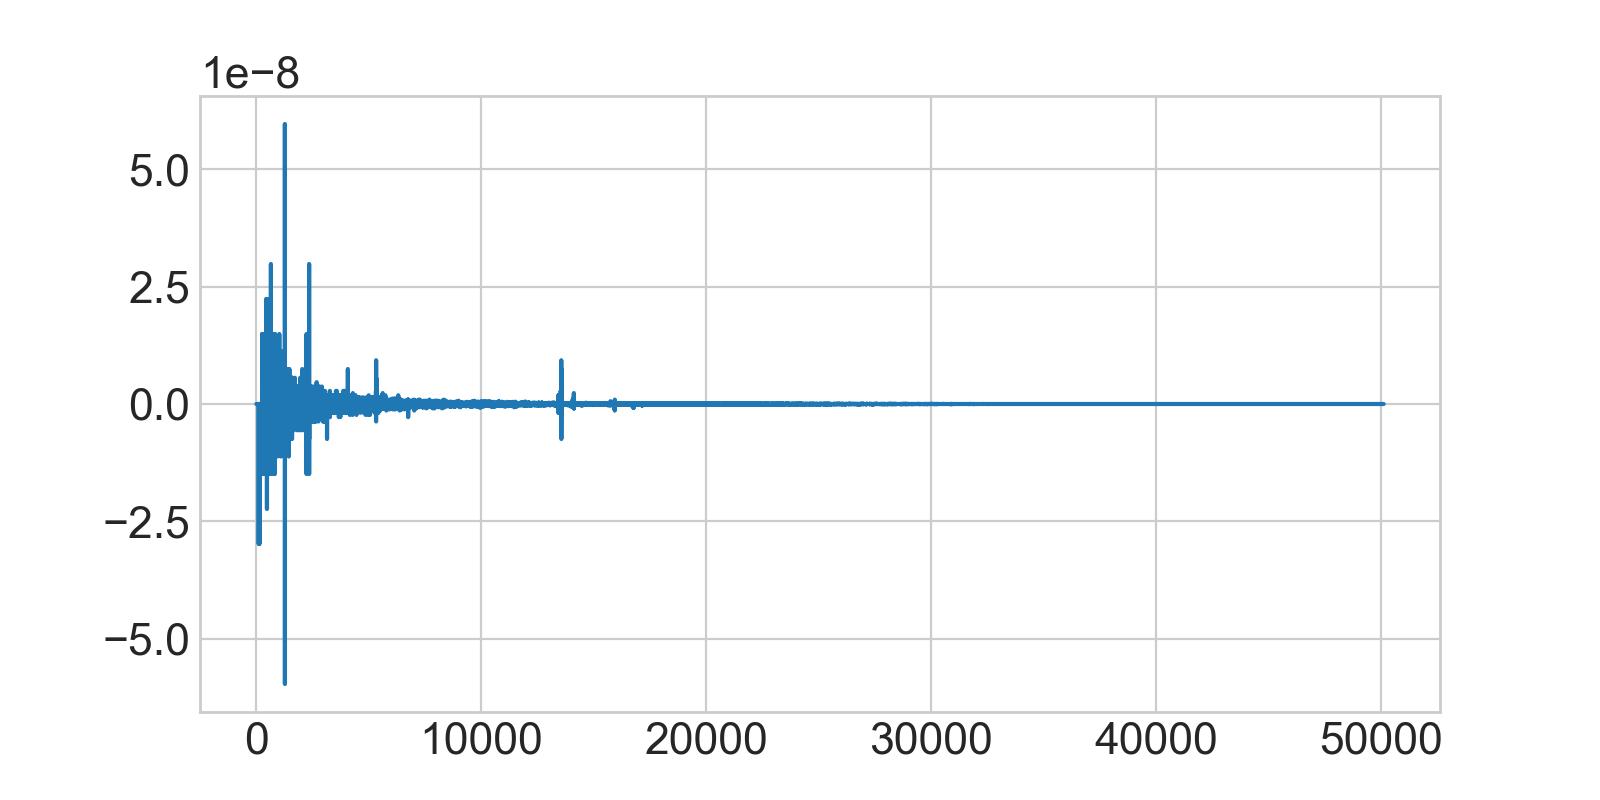

In [326]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))

ax.plot(spec_b_new.detach().numpy() - spec_b_old.detach().numpy())

Second attempt, using vectors:

In [181]:
#initialize thes
fit = spexai.inference.fit_new.SingleTemp(torch.Tensor(counts), combined_model, priors_all,
                 e_min=None, e_max=15.0, fdir_nn='neuralnetworks/')

Using cpu


In [ ]:
np.seterr(all="ignore") #ignore RuntimeWarning error prints
fit.fit_spectrum(20, 100)

(20, 7)


  5%|██▏                                        | 5/100 [01:25<27:41, 17.49s/it]

In [ ]:
'''This step can take a long time to run'''
np.seterr(all="ignore")#ignore RuntimeWarning error prints
fit.fit_spectra(add_prior=add_prior)

### Evaluating the fit results

The progress of the walker can be visualized in a timeseries giving the parameter values for each walker at each step in the chain.

In [ ]:
fit.plot_timeseries()

The results of the fit can visualized with a cornerplot. ```Fit.cornerplot``` is also able to save the sampled posterior in an .csv format by giving a directory name ```fitdir```.  In this example you discard the first ```100``` steps in the chain ```discard``` and only reading every 15th step ```thin```. The corner plot can also be oveploted with the true values of the parameters by giving a list ```true_values```, where the values shoud be same order as the prior.

In [ ]:
#true_val = [temp,   met,    vel,    logz    norm,   Z8,    Z14]
true_val =  [5,      1,      100,    -2,     1e10,   1.2,   0.9]

fit.cornerplot(600, thin=10, fitdir=None, true_values=true_val)

The fit results can be directly compared to the data by overplotting the fitted model with parameters drawn from the posterior to the observed data, the number of samples it overplots is given by ```nsample```. Also prints the mean and 1-sigma interval of the fitted parameters.

In [ ]:
'''This step can take a long time to run'''
fit.plot_spectrum(nsample=20)

## Fitting a Two-Temperature Model

Simulated data or real data can be model with a one temperuture model by  ```TwoTemp``` a subclass of Fit

The paramater that are fitted are the 
- First temperature in KeV  ```temp1``` (between 0.2 and 10 KeV)
- Second temperature in KeV  ```temp2``` (between 0.2 and 10 KeV)
- Metalicity [Z_solar] ```met```  (larger then 0)
- Turbulent velocity in km/sec ```vel``` (between 0 and 600 km/sec)
- Redshift in log10(z) ```logz``` (between -10 and 1)
- First normalisation ```norm1``` (between 1e5 and 1e15)
- Second normalisation ```norm2``` (between 1e5 and 1e15)

Additional parameter(s)
- Single element ```X``` abundace ratio with respect to Iron ```ZX```, where ```X``` is tha atom number (larger then 0)

The intial guess with there standard diviation of all the parameters that are fitted can be put into the dictiornary of the ```prior```.

In [ ]:
#intial guess and prior for fit
prior = {
        'temp1': {'mu': 4.5,    'sigma': 2},
        'temp2': {'mu': 6,    'sigma': 2},
        'met' : {'mu': 1,    'sigma': .3},
        'vel' : {'mu': 100,  'sigma': 50},
        'logz': {'mu': -5,   'sigma': 2},
        'norm1': {'mu': 1e10, 'sigma': 5e9},
        'norm2': {'mu': 1.5e10, 'sigma': 5e9}
        }

The ensemble samper can be intialized with ```nwalkers``` and ```nsteps``` for the walker to go through, ```prior``` indicates the intial values for the parameters and there Gaussion prior in the likelihood, other parameter that can be initialized are the Luminosity Distance in m and the energy interval of the spectrum in KeV (```e_min``` > 0.1; ```e_max``` < 25).

```fdir_nn``` is the file directory to the trained neural networks and should match the path on your device.

In [ ]:
#initialize the
fit_2t = TwoTemp(50, 800, prior, Luminosity_Distance=1e25, fdir_nn='/home/jmatthijss/spexai_code/neuralnetworks/', e_max=15)

### Reading in the FITS files

To be able to fit real data the response of the telescope can be read in by the FITS file, for the Response Matrix File (RMF), effective area response file (ARF).

The data used for fitting can be read in from a FITS file of the observed data ```TwoTemp.load_data```, or can be simulated by the model with ```TwoTemp.sim_data(params)``` here ```params``` is a dictornary with the parameter names and there values.

In addition the response files there is a sparse matrix (```make_sparsex```) used for convulation that implements line broadening to the spectra. The speed an accuracy of the line broadening is strongly dependent on the kernel size of the convulolution ```n``` and the default ```n=300```, increasing ```n``` will make the line-broading more accurete but will also segnifcanly impact the speed.

In [ ]:
'''This step can take a long time to run'''
#reading in the response matrix file
fit_2t.combined_model.load_rm('/home/jmatthijss/obs234_HP_obs234_all_det/obs234_HP_obs234_all_det_he.rmf')

In [ ]:
#reading in the effective area
fit_2t.combined_model.load_arf('/home/jmatthijss/obs234_HP_obs234_all_det/obs234_HP_obs234_all_det_point_he.arf')

In [ ]:
'''This step can take a long time to run'''
#initializing the sparse matrix for the convolution from line-broadening
fit_2t.combined_model.load_sparsematrix_x(n=200)

In [ ]:
#create your own data
params = {'temp1':4, 'temp2':5.8, 'logz':-2, 'vel':100, 'met':1.2, 'norm1':8e9, 'norm2':1.2e10}
fit_2t.sim_data(params, exp_time=50000)

__Add aditional parameters__

Single element abundace that differ with respect to the overall metalicity and Iron can be added in as extra parameter(s).
These are writen in the format ```'ZX'``` with ```X``` the atom number of the elements. ```add_prior``` gives the prior and intial  values of the added paramater(s).

In [ ]:
#names of aditional fitted parameters 
add_prior = {'Z8':{'mu':1, 'sigma':.3},'Z14':{'mu':1, 'sigma':.3}}

### Run Ensemble Sampler Fit

Then after ensemble sampler has been fully intialized the data can be fitted with ```Fit.fit_spectra``` making use of ```emcee``` algorithm.
```TwoTemp.fit_spectra``` will also print the integrated autocorrelation time to give an indication of the burn-in time.

In [ ]:
'''This step can take a long time to run'''
np.seterr(all="ignore")#ignore RuntimeWarning error prints
fit_2t.fit_spectra(add_prior=add_prior)

### Evaluating the fit results

The progress of the walker can be visualized in a timeseries giving the parameter values for each walker at each step in the chain.

In [ ]:
fit_2t.plot_timeseries()

The results of the fit can visualized with a cornerplot. ```TwoTemp.cornerplot``` is also able to save the sampled posterior in an .csv format by giving a directory name ```fitdir```.  In this example you discard the first ```100``` steps in the chain ```discard``` and only reading every 15th step ```thin```. The corner plot can also be oveploted with the true values of the parameters by giving a list ```true_values```, where the values shoud be same order as the prior.

In [ ]:
#true_val = [temp1, temp2,  met,    vel,    logz    norm1,  norm2,  Z8,    Z14]
true_val =  [4,     5.8,    1,      100,    -2,     8e9,    1.2e10, 1.2,   0.9]

fit_2t.cornerplot(600, thin=10, fitdir=None, true_values=true_val)

The fit results can be directly compared to the data by overplotting the fitted model with parameters drawn from the posterior to the observed data, the number of samples it overplots is given by ```nsample```. Also prints the mean and 1-sigma interval of the fitted parameters.

In [ ]:
'''This step can take a long time to run'''
fit_2t.plot_spectrum(nsample=20)

## Fitting a Multi-Temperature Distribution Model

This uses a Subclass of ```Fit```, ```TempDist``` to fit a model with a multi-temperature distribution.

The temperature need to give a function that outputs a temperature grid and temperature distribution described by parameters. The output of the temperature grid should always be inbetween 0.2 and 10 KeV and linearly spaced and the distribution should always be normalized.

In this exapmle we look at a Normal Distribution for our temperature distribution, parametrized by a mean temperature and standard devitation.

The paramater that are fitted
- Mean Temperature in KeV ```mean_temp``` (between 0.2 and 10)
- Standard divation of Temperature in log(KeV) ```log_sd_temp``` (between -5, 0.3)
- Metalicity [Z_solar] ```met```  (larger then 0)
- Turbulent velocity in km/sec ```vel``` (between 0 and 600 km/sec)
- Redshift in log10(z) ```logz``` (between -10 and 1)
- Normalisation ```norm``` (between 1e5 and 1e15)

Additional parameter(s)
- Single element ```X``` abundace ratio with respect to Iron ```ZX```, where ```X``` is tha atom number (larger then 0)

The intial guess with there standard diviation can be put into the dictiornary of the ```prior```.

In [ ]:
def normal_dist(params):
    '''
    Normal Distribution with stdev in logspace
    Parameters
    ----------
    params: dict
        dictionary with the keys of distribution parameters
        in this case 'mean_temp' and 'log_sd_temp'
    '''
    #intialize temperature grid
    low = max(params['mean_temp']-5*10**params['log_sd_temp'], 0.2)
    high = min(params['mean_temp']+5*10**params['log_sd_temp'], 10)
    temp_grid = np.linspace(low, high,  500)
    
    #Gaussion distribution
    mean = params['mean_temp']
    sd = 10**params['log_sd_temp']
    temp_dist = 1/(np.sqrt(2*np.pi)*sd**2) * np.exp(-0.5*((temp_grid-mean)/sd)**2)
    
    #normalize the function 
    temp_dist = temp_dist/np.sum(temp_dist*np.mean(np.diff(temp_grid)))
    return temp_grid, temp_dist

#define allowed interval of parameter of the distribution
interval = {
            'mean_temp': [0.2,10],
            'log_sd_temp'  : [-5, 0.3]
           }

The intial guess with there standard diviation of all the parameters that are fitted can be put into the dictiornary of the ```prior```.

In [ ]:
#intial guess and prior for temp run
prior = {
        'mean_temp': {'mu': 4, 'sigma': 1},
        'log_sd_temp'  : {'mu': 0, 'sigma': 1},
        'met'      : {'mu': 0.6, 'sigma': .3},
        'vel'      : {'mu': 160, 'sigma': 25},
        'logz'     : {'mu': np.log10(0.017284),  'sigma': 0.05},
        'norm'     : {'mu': 2e10, 'sigma': 1e9}
        }

The ensemble samper can be intialized with ```nwalkers``` and ```nsteps``` for the walker to go through, the prior ```prior```, for the TempDist we need to give the function that returns a normalized temperature distribution with the temperature grid ```normal_dist``` and the bound interval of this ditributions parameter ```interval```, other parameter that can be initialized are the Luminosity Distance in m and the energy interval of the spectrum in KeV (```e_min, e_max```).

In [ ]:
#initialize the
fit_dist = TempDist(40, 2, prior, normal_dist, interval, Luminosity_Distance=9.461e24, e_min=2, e_max=9, fdir_nn='/home/jmatthijss/spexai_code/neuralnetworks/')

### Reading in the FITS files

To be able to fit real data the response of the telescope can be read in by the FITS file, for the Response Matrix File (RMF), effective area response file (ARF) and the FITS file of the observed data.

In addition the response files there is a sparse matrix (```make_sparsex```) used for convulation that implements line broadening to the spectra. The speed an accuracy of the line broadening is strongly dependent on the kernel size of the convulolution ```n``` and the default ```n=300```, increasing ```n``` will make the line-broading more accurete but will also segnifcanly impact the speed.

In [ ]:
'''This step can take a long time to run'''
#reading in the response matrix file
fit_dist.combined_model.load_rm('/home/jmatthijss/obs234_HP_obs234_all_det/obs234_HP_obs234_all_det_he.rmf')

In [ ]:
#reading in the effective area
fit_dist.combined_model.load_arf('/home/jmatthijss/obs234_HP_obs234_all_det/obs234_HP_obs234_all_det_point_he.arf')

In [ ]:
'''This step can take a long time to run'''
#initializing the sparse matrix for the convolution from line-broadening
fit_dist.combined_model.load_sparsematrix_x(n=200)

Now instead of simulating the data we are reading it in from a FITS file

In [ ]:
#reading in the data
fit_dist.load_data('/home/jmatthijss/obs234_HP_obs234_all_det/obs234_HP_obs234_all_det_valign_gcor_he.pi')


#### Add aditional parameters

Single element abundace that differ with respect to the overall metalicity and Iron can be added in as extra parameter(s).
These are writen in the format ```'ZX'``` with ```X``` the atom number of the elements. ```add_prior``` gives the prior and intial  values of the added paramater(s).

In [ ]:
#names of aditional fitted parameters 
add_prior = {'Z8':{'mu':1, 'sigma':.3},'Z14':{'mu':1, 'sigma':.3}}

Then after ensemble sampler has been fully intialized the data can be fitted with ```TempDist.fit_spectra``` making use of ```emcee``` algorithm.
```TempDist.fit_spectra``` will aslo print the the integrated autocorrelation time to give an indication of the burn-in time.

In [ ]:
import torch
import matplotlib.pyplot as plt
def normal_dist(x , mean , sd):
    sd = torch.tensor(sd, dtype=torch.float32, device=x.device)
    prob_density = 1/(torch.sqrt(torch.tensor(2*np.pi, dtype=torch.float32, device=x.device)*sd**2)) * torch.exp(-0.5*((x-torch.tensor(mean, dtype=torch.float32, device=x.device))/sd)**2)
    return prob_density

In [ ]:
params = {'Temperature [KeV]': 4, 'Temp Stdev log[KeV]': -2, 'Redshift [log(z)]': np.log10(0.017284), 'Velocity [km/sec]': 160, 'Metalicity [Fe/H]': .7, 'Normalisation': 2e10}

dict_abund = {}
for i in torch.arange(6,31):
    dict_abund[f'Z{i}'] = params['Metalicity [Fe/H]']
    for key in params.keys():
        if key == f'Z{i} [Z{i}/Fe]':
            dict_abund[f'Z{i}'] = params['Metalicity [Fe/H]']*params[f'Z{i} [Z{i}/Fe]']
low = max(params['Temperature [KeV]']-5*10**params['Temp Stdev log[KeV]'], 0.1)
high = min(params['Temperature [KeV]']+5*10**params['Temp Stdev log[KeV]'],10)
temp_grid = torch.linspace(low, high, 500, dtype=torch.float32, device='cuda')
temp_dist = normal_dist(temp_grid, params['Temperature [KeV]'], 10**params['Temp Stdev log[KeV]'])
temp_dist = temp_dist/torch.sum(temp_dist*torch.mean(torch.diff(temp_grid)))
with torch.no_grad():
    ymodel = fit_dist.combined_model(temp_grid, temp_dist, dict_abund, params['Redshift [log(z)]'], 
                    params['Normalisation'], params['Velocity [km/sec]'])
plt.plot(ymodel[fit_dist.intv].cpu().detach())
plt.yscale('log')
plt.ylim(1e-2,1e1)



In [ ]:
'''This step can take a long time to run'''
np.seterr(all="ignore")#ignore RuntimeWarning error prints
fit_dist.fit_spectra(add_prior=add_prior)

### Evaluating the fit results

The progress of the walker can be visualized in a timeseries giving the parameter values for each walker at each step in the chain.

In [ ]:
fit_dist.plot_timeseries()

The results of the fit can visualized with a cornerplot. ```TempDist.cornerplot``` is also able to save the sampled posterior in an .csv format by giving a directory name ```fitdir```.  In this example you discard the first ```100``` steps in the chain ```discard``` and only reading every 15th step ```thin```. The corner plot can also be oveploted with the true values of the parameters by giving a list ```true_values```, where the values shoud be same order as the prior.

In [ ]:
#true_val = mean_temp,  log_sd_temp,    met,    vel,    logz    norm,   Z8, Z14

fit_dist.cornerplot(1, thin=1, fitdir=None, true_values=None)

The fit results can be directly compared to the data by overplotting the fitted model with parameters drawn from the posterior to the observed data, the number of samples it overplots is given by ```nsample```. Also prints the mean and 1-sigma interval of the fitted parameters.

In [ ]:
'''This step can take a long time to run'''
fit_dist.plot_spectrum(nsample=20)